Cell 1 — Imports & Setup (Code Cell)

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score, confusion_matrix
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

Cell 2 — Load + Clean Data (Code Cell)
## 1. Data Loading and Preprocessing

In [2]:
# Load CSV
df = pd.read_csv('gym_members_exercise_tracking.csv')

# Missing Values
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# One-hot encode
df = pd.get_dummies(df, columns=['Gender', 'Workout_Type'])

# Ensure Experience_Level numeric
df['Experience_Level'] = df['Experience_Level'].astype(float)

# Feature Engineering
df['Workout_Intensity'] = df['Avg_BPM'] / df['Resting_BPM']

df.head()


,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Gender_Female,Gender_Male,Workout_Type_Cardio,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga,Workout_Intensity
0,56,88.3,1.71,180,157,60,1.69,1313.0,12.6,3.5,4,3.0,30.20,False,True,False,False,False,True,2.616667
1,46,74.9,1.53,179,151,66,1.30,883.0,33.9,2.1,4,2.0,32.00,True,False,False,True,False,False,2.287879
2,32,68.1,1.66,167,122,54,1.11,677.0,33.4,2.3,4,2.0,24.71,True,False,True,False,False,False,2.259259
3,25,53.2,1.70,190,164,56,0.59,532.0,28.8,2.1,3,1.0,18.41,False,True,False,False,True,False,2.928571
4,38,46.1,1.79,188,158,68,0.64,556.0,29.2,2.8,3,1.0,14.39,False,True,False,False,True,False,2.323529


Cell 3 — Train/Test Split and Scaling (Code Cell)

In [3]:
target = 'Calories_Burned'
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [4]:
# Create classes from continuous Calories_Burned to use accuracy and confusion matrix
# Here we use 3 classes based on quantiles: Low, Medium, High

num_classes = 3

all_y = np.concatenate([y_train.values, y_test.values])
bins = np.quantile(all_y, np.linspace(0, 1, num_classes + 1))

# Small padding so extremes are included
bins[0] -= 1e-3
bins[-1] += 1e-3

class_names = ['Low', 'Medium', 'High']

def to_classes(values, bins):
    """Convert continuous values to discrete class indices 0..num_classes-1."""
    return np.digitize(values, bins[1:-1])



Cell 4 — Convert to PyTorch Tensors (Code Cell)

Cell 5 — Model Architecture + Training Loop (Code Cell)

In [5]:
# Device and tensor conversion
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test.values).view(-1, 1).to(device)

# Model definition
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.layers(x)

input_dim = X_train.shape[1]
model = MLP(input_dim).to(device)

# Training setup
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
batch_size = 32
epochs = 100

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Lists for plotting
train_losses = []
train_accuracies = []

# Training loop
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

    # Average loss this epoch
    epoch_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_loss)

    # Accuracy on the whole training set (after binning)
    model.eval()
    with torch.no_grad():
        train_pred = model(X_train_tensor).cpu().numpy().flatten()
        train_true = y_train_tensor.cpu().numpy().flatten()

    train_pred_classes = to_classes(train_pred, bins)
    train_true_classes = to_classes(train_true, bins)
    epoch_acc = accuracy_score(train_true_classes, train_pred_classes)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.4f}")



Epoch [1/100] - Loss: 888792.9577 - Acc: 0.3278
Epoch [2/100] - Loss: 886970.0141 - Acc: 0.3278
Epoch [3/100] - Loss: 878596.1181 - Acc: 0.3278
Epoch [4/100] - Loss: 848860.3618 - Acc: 0.3278
Epoch [5/100] - Loss: 770954.0395 - Acc: 0.3278
Epoch [6/100] - Loss: 615968.3760 - Acc: 0.3278
Epoch [7/100] - Loss: 386541.1172 - Acc: 0.3728
Epoch [8/100] - Loss: 173935.2338 - Acc: 0.4961
Epoch [9/100] - Loss: 76319.4651 - Acc: 0.5694
Epoch [10/100] - Loss: 48330.0495 - Acc: 0.6041
Epoch [11/100] - Loss: 37553.0674 - Acc: 0.5990
Epoch [12/100] - Loss: 31815.4056 - Acc: 0.6144
Epoch [13/100] - Loss: 27770.6017 - Acc: 0.6311
Epoch [14/100] - Loss: 24512.7501 - Acc: 0.6375
Epoch [15/100] - Loss: 21849.1022 - Acc: 0.6555
Epoch [16/100] - Loss: 19698.0553 - Acc: 0.6594
Epoch [17/100] - Loss: 17815.5795 - Acc: 0.6825
Epoch [18/100] - Loss: 16156.9351 - Acc: 0.6954
Epoch [19/100] - Loss: 14766.1278 - Acc: 0.7134
Epoch [20/100] - Loss: 13521.1771 - Acc: 0.7237
Epoch [21/100] - Loss: 12473.4901 - Acc: 

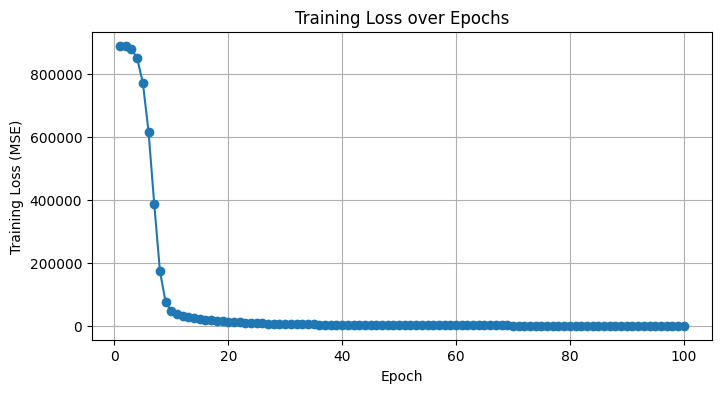

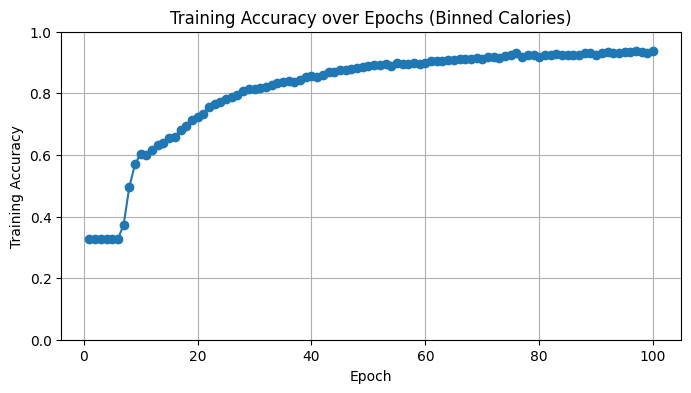

In [6]:
# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss (MSE)')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()

# Plot training accuracy
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), train_accuracies, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy over Epochs (Binned Calories)')
plt.ylim(0, 1)
plt.grid(True)
plt.show()




Cell 6 — Evaluation (Code Cell)
## 5. Model Evaluation

MSE: 1966.4830322265625
R2: 0.9764281511306763
Test Accuracy (binned classes): 0.9333


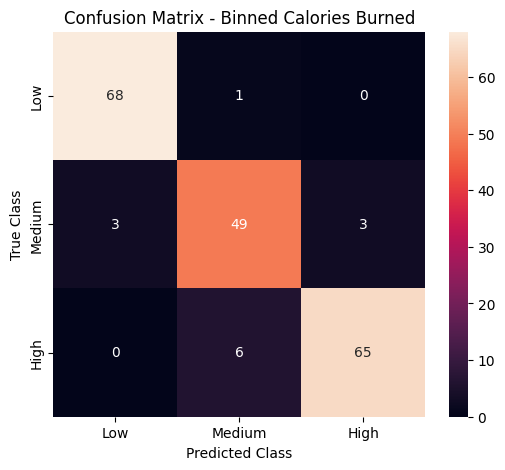

In [7]:
# Evaluation on test set
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor).cpu().numpy().flatten()
    y_true = y_test_tensor.cpu().numpy().flatten()

mse = mean_squared_error(y_true, predictions)
r2 = r2_score(y_true, predictions)

print(f"MSE: {mse}")
print(f"R2: {r2}")

# Convert to classes for accuracy and confusion matrix
y_true_classes = to_classes(y_true, bins)
y_pred_classes = to_classes(predictions, bins)

test_acc = accuracy_score(y_true_classes, y_pred_classes)
print(f"Test Accuracy (binned classes): {test_acc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix - Binned Calories Burned')
plt.show()

